# Figure 3: Cross-Condition Generalization of Truth Directions

**Paper Context**: *Testing the Limits of Truth Directions in LLMs* (Poulis et al., 2026)

## Experimental Objective
Poulis et al.'s **Figure 3** asks whether a truth direction learned under one prompt condition still separates true from false in the activations produced under a *different* prompt condition. In the original paper this is done in one direction only (unprompted plaintext → `ask-correct`).

This notebook is a **parameterized pipeline**: set `condition_A` and `condition_B` in the setup cell to any two keys of `CONDITION_DICT`, and it evaluates **both transfer directions** across **every layer**:

1. **A → B**: fit the probe on `condition_A`'s train split ($\mathbf{w}_A, \boldsymbol{\mu}_A$), score on `condition_B`'s test split — $\text{logits} = (\mathbf{X}_{B,\text{test}} - \boldsymbol{\mu}_A)\,\mathbf{w}_A$.
2. **B → A**: the mirror — fit on `condition_B`'s train split, score on `condition_A`'s test split.

AUROC is recorded against ground-truth labels in both cases.

## Key Specifications & Methodology
- **Model**: `deepseek-ai/DeepSeek-R1-Distill-Llama-8B` in `torch.float16`.
- **Tasks (9)**: Arithmetic ($A_1$–$A_3$) and Factual/Compositional ($F_0$–$F_5$).
- **Token Extraction**: from the canonical `extracted_statement_ids` column (parsed with `ast.literal_eval`), length-sorted batching, left-padded with an attention mask, taking the final-token residual stream at **every** layer $l \in [0, L]$.
- **Probe (Poulis Appendix A.4 parity)**: no-bias, train-mean-centered linear probe ($d \to 1$), Adam (`lr=1e-3`, `weight_decay=0.1`), 1000 steps, `BCEWithLogitsLoss`.
- **All layers are computed and stored.** Downstream figures select whichever layers they need (15/20/25/30, etc.) from the saved rows — adding a new figure never requires re-running extraction.
- **Optional activation cache** (`CACHING` in the setup cell, default `False`). When on, per-split activations are written to `experiments/cache_cross_condition/` and reused on the next run, so you can iterate on probing without repeating the forward passes. The cache key includes the *condition*, so switching condition pairs cannot silently reuse the previous pair's activations. It is measured in GBs per pair and is not gitignored by default — leave it off unless iterating.
- **Output**: rows appended to `experiments/results_database.csv` (`train_condition` / `test_condition` record the direction); figures written to `experiments/figures/figure_3/`, filenames tagged with the condition pair so different pairs don't overwrite each other.

In [1]:
import os
import sys
import gc
from ast import literal_eval
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    repo_colab_path = '/content/Algoverse_Truth_Directions_Research'
    if not os.path.exists(repo_colab_path):
        os.system(f'git clone https://github.com/boracandan/Algoverse_Truth_Directions_Research.git {repo_colab_path}')
    if os.path.exists(repo_colab_path):
        os.chdir(repo_colab_path)
        if repo_colab_path not in sys.path:
            sys.path.append(repo_colab_path)

def resolve_repo_root():
    cwd = os.path.abspath(os.getcwd())
    candidates = [
        cwd,
        '/content/Algoverse_Truth_Directions_Research',
        os.path.abspath(os.path.join(cwd, '..')),
        '/content/drive/MyDrive/Algoverse_Truth_Directions_Research'
    ]
    for path in candidates:
        if os.path.exists(os.path.join(path, 'datasets', 'plain_template_dataset')):
            return path
    return cwd


ROOT_DIR = resolve_repo_root()
os.chdir(ROOT_DIR)
if ROOT_DIR not in sys.path:
    sys.path.append(ROOT_DIR)

print(f'Workspace root: {ROOT_DIR}')
print(f'PyTorch: {torch.__version__} | CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)} ({torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB)')


Workspace root: c:\Users\Faruk\Code\Algoverse_Project
PyTorch: 2.11.0+cu128 | CUDA: True
GPU: NVIDIA GeForce RTX 4090 (25.76 GB)


In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_id = 'deepseek-ai/DeepSeek-R1-Distill-Llama-8B'

if IN_COLAB and not torch.cuda.is_available():
    raise RuntimeError('Colab runtime must have a GPU enabled.')

print(f'Loading {model_id} in float16...')
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9 if torch.cuda.is_available() else 0

if vram_gb >= 14.0:
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        dtype=torch.float16,
        device_map='cuda',
        trust_remote_code=True
    )
elif vram_gb > 4.0:
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        dtype=torch.float16,
        device_map='auto',
        max_memory={0: '5GiB', 'cpu': '24GiB'},
        trust_remote_code=True
    )
else:
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        dtype=torch.float16,
        device_map='cpu',
        trust_remote_code=True
    )

tokenizer = AutoTokenizer.from_pretrained(model_id)

model.eval()
num_layers = model.config.num_hidden_layers + 1
hidden_dim = model.config.hidden_size
print(f'Model loaded: {num_layers} layers, hidden_dim={hidden_dim}')


Loading deepseek-ai/DeepSeek-R1-Distill-Llama-8B in float16...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Model loaded: 33 layers, hidden_dim=4096


In [3]:
from pathlib import Path

# Anchored to ROOT_DIR, not a relative "../datasets": cell 1 does os.chdir(ROOT_DIR), so the
# working directory is already the repo root and a relative "../" would land outside it.
DATA_DIR = Path(ROOT_DIR) / "datasets"

CONDITION_DICT = {
    "no-prompt": DATA_DIR / "plain_dataset",
    "cot-zero-shot": DATA_DIR / "CoT_datasets" / "lexically_cleaned",
    "sentence-based-CoT": DATA_DIR / "CoT_datasets" / "sentence_based_lexically_cleaned",
    "no-prompt-chat-template": DATA_DIR / "plain_template_dataset",
    "ablation-filler-token": DATA_DIR / "ablation_datasets" / "filler_token_only",
    # instructions + chat template (folder renamed from "instructions_only")
    "ablation-instructions-and-template": DATA_DIR / "ablation_datasets" / "instructions_and_template",
    # instructions with NO chat template -- the genuine instructions-only control
    "ablation-instructions-only": DATA_DIR / "ablation_datasets" / "instructions_only",
}

# ---------------------------------------------------------------------------------
# RUN CONFIGURATION -- the only things you normally change.
# ---------------------------------------------------------------------------------

# The two conditions to transfer between. Both directions are always evaluated:
#   A -> B  (probe trained on condition_A, scored on condition_B's test split)
#   B -> A  (probe trained on condition_B, scored on condition_A's test split)
condition_A = "no-prompt"
condition_B = "sentence-based-CoT"

# Cache extracted activations to disk so a re-run skips the (expensive) forward passes and
# goes straight to probing. Useful when iterating on the probe/analysis for a fixed pair.
#
# Cost: roughly 4 splits x N samples x num_layers x hidden_dim x 4 bytes per task -- on the
# order of GBs per condition pair. The cache directory is NOT gitignored by default, so
# leave this False unless you are actually iterating, and clear the directory when done.
CACHING = False
CACHE_DIR = Path(ROOT_DIR) / "experiments" / "cache_cross_condition"

assert condition_A in CONDITION_DICT, f"unknown condition_A: {condition_A}"
assert condition_B in CONDITION_DICT, f"unknown condition_B: {condition_B}"
assert condition_A != condition_B, "condition_A and condition_B must differ"

print(f"Cross-condition pair: {condition_A}  <->  {condition_B}")
print(f"Activation caching: {'ON -> ' + str(CACHE_DIR) if CACHING else 'OFF (extract fresh each run)'}")

Cross-condition pair: no-prompt  <->  sentence-based-CoT
Activation caching: OFF (extract fresh each run)


In [4]:
def update_batch_size(pbar, current_batch_size, previous_rate):
    """Halve the batch size if throughput (rows/sec) has dropped by more than half since the
    last check -- a proxy for "sequences got a lot longer, back off".

    pbar.format_dict is tqdm's own snapshot of its stats; 'rate' is its rows/sec estimate
    (None on the very first check, before tqdm has timing data). Note it is format_dict,
    not any attribute on the bar itself -- tqdm has no `.rate`/`.mae` attribute.
    """
    if current_batch_size == 1 or previous_rate is None:
        return current_batch_size, pbar.format_dict.get('rate')

    current_rate = pbar.format_dict.get('rate')
    if current_rate is not None and current_rate < previous_rate / 2:
        return max(1, current_batch_size // 2), current_rate

    return current_batch_size, previous_rate if previous_rate is not None else current_rate


def extract_all_layer_activations(statement_ids_col, model, batch_size=4, desc='Extracting'):
    """Final-token residual stream at every layer, for one split.

    Sequences are length-sorted before batching so each batch holds similar-length rows --
    without it a single long trace forces its whole batch to pad up to that length. Results
    are un-sorted back to the caller's row order at the end via inverse_idx.

    `batch_size` is the STARTING size: it is halved (floor 1) whenever throughput collapses,
    which happens toward the tail of a sorted split where the longest sequences live and
    attention cost grows quadratically. Because the size changes mid-run, this uses a manual
    tqdm (total + update) and a while loop -- a `for i in range(0, n, batch_size)` would bake
    the stride in at construction, so later reassignment would silently skip or duplicate rows.
    """
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    parsed_ids = [
        literal_eval(x) if isinstance(x, str) else list(x)
        for x in statement_ids_col
    ]
    tensors = [torch.tensor(id_list, dtype=torch.long) for id_list in parsed_ids]
    lengths = torch.tensor([len(t) for t in tensors])

    sort_idx = torch.argsort(lengths)
    inverse_idx = torch.argsort(sort_idx)
    sorted_tensors = [tensors[i] for i in sort_idx.tolist()]

    total_layers = model.config.num_hidden_layers + 1
    per_layer_acts = [[] for _ in range(total_layers)]
    target_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    pad_token_id = 128001

    total_samples = len(sorted_tensors)
    pbar = tqdm(total=total_samples, desc=desc, leave=False)

    previous_rate = None
    i = 0
    n_batches = 0

    while i < total_samples:
        n_batches += 1
        # Every 10 batches: free cached blocks and re-check throughput. Not every iteration --
        # per-iteration empty_cache() costs more than it saves.
        if n_batches % 10 == 0:
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            batch_size, previous_rate = update_batch_size(pbar, batch_size, previous_rate)
            pbar.set_postfix(bs=batch_size, refresh=False)

        batch = sorted_tensors[i : i + batch_size]  # slice clips on the final short batch

        padded = torch.nn.utils.rnn.pad_sequence(
            batch, batch_first=True, padding_value=pad_token_id, padding_side='left'
        ).to(target_device)

        attention_mask = (padded != pad_token_id).long().to(target_device)

        with torch.no_grad():
            outputs = model(input_ids=padded, attention_mask=attention_mask, output_hidden_states=True)

        for layer_idx, layer_hidden in enumerate(outputs.hidden_states):
            final_token = layer_hidden[:, -1, :].float().cpu()
            per_layer_acts[layer_idx].append(final_token)

        del outputs, padded, attention_mask
        pbar.update(len(batch))
        i += batch_size

    pbar.close()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    all_layers_numpy = []
    for layer_acts in per_layer_acts:
        full_layer_tensor = torch.cat(layer_acts, dim=0)[inverse_idx]
        all_layers_numpy.append(full_layer_tensor.numpy())

    return all_layers_numpy


In [5]:
def fit_linear_probe(X_train, y_train, device='cuda' if torch.cuda.is_available() else 'cpu'):
    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    train_mean = X_train_t.mean(dim=0)
    X_centered = (X_train_t - train_mean).to(device)
    y_t = torch.tensor(y_train, dtype=torch.float32).to(device)

    probe = nn.Linear(X_train.shape[1], 1, bias=False).to(device)
    optimizer = torch.optim.Adam(probe.parameters(), lr=1e-3, weight_decay=0.1)
    loss_fn = nn.BCEWithLogitsLoss()

    for _ in range(1000):
        optimizer.zero_grad()
        logits = probe(X_centered).squeeze(-1)
        loss = loss_fn(logits, y_t)
        loss.backward()
        optimizer.step()

    w = probe.weight.detach().cpu().numpy().flatten()
    return w, train_mean.numpy()

def evaluate_probe_cross_condition(w, train_mean, X_test, y_test):
    X_test_centered = X_test - train_mean
    test_logits = X_test_centered @ w
    try:
        score = roc_auc_score(y_test, test_logits)
    except ValueError:
        score = 0.5
    return float(score)


In [6]:
TASKS = ['A1', 'A2', 'A3', 'F0', 'F1', 'F2', 'F3', 'F4', 'F5']
COND_A_DIR = CONDITION_DICT[condition_A]
COND_B_DIR = CONDITION_DICT[condition_B]
CSV_PATH = os.path.join(ROOT_DIR, 'experiments', 'results_database.csv')

if CACHING:
    CACHE_DIR.mkdir(parents=True, exist_ok=True)

# AUROC is computed and stored for EVERY layer. Figures downstream pick whichever layers
# they want (15/20/25/30 etc.) from the saved rows -- nothing is filtered at compute time,
# so a new figure never requires re-running extraction.

def get_acts(statement_ids, task, condition, split):
    """Activations for one (task, condition, split), optionally disk-cached.

    The cache key includes the CONDITION, not just task+split. That matters: this notebook
    is parameterized over condition pairs, so a key of the form '{task}_{split}' would make
    a second pair silently load the first pair's activations.
    """
    if not CACHING:
        return extract_all_layer_activations(
            statement_ids, model, batch_size=4, desc=f'{task} {condition} {split}'
        )

    cache_file = CACHE_DIR / f'{task}__{condition}__{split}.pt'
    if cache_file.exists():
        print(f'  Loaded cached activations: {cache_file.name}')
        return torch.load(cache_file, weights_only=False)

    acts = extract_all_layer_activations(
        statement_ids, model, batch_size=4, desc=f'{task} {condition} {split}'
    )
    torch.save(acts, cache_file)
    return acts


def append_rows_to_database(new_rows, csv_path):
    new_df = pd.DataFrame(new_rows)
    if os.path.exists(csv_path):
        existing_df = pd.read_csv(csv_path)
        keys = ['train_task', 'test_task', 'train_condition', 'test_condition', 'layer', 'model']
        merged = pd.concat([existing_df, new_df], ignore_index=True)
        merged = merged.drop_duplicates(subset=keys, keep='last')
        merged.to_csv(csv_path, index=False)
    else:
        new_df.to_csv(csv_path, index=False)

total_new_rows = []

for task in TASKS:
    print(f'\nProcessing Task: {task}  ({condition_A} <-> {condition_B})')
    task_rows = []

    df_a_tr = pd.read_csv(os.path.join(COND_A_DIR, f'{task}_train.csv'))
    df_a_te = pd.read_csv(os.path.join(COND_A_DIR, f'{task}_test.csv'))
    df_b_tr = pd.read_csv(os.path.join(COND_B_DIR, f'{task}_train.csv'))
    df_b_te = pd.read_csv(os.path.join(COND_B_DIR, f'{task}_test.csv'))

    if "extracted_statement_ids" not in df_a_tr.columns:
        df_a_tr['extracted_statement_ids'] = tokenizer(df_a_tr['statement'].to_list())["input_ids"]
        df_a_te['extracted_statement_ids'] = tokenizer(df_a_te['statement'].to_list())["input_ids"]

    if "extracted_statement_ids" not in df_b_tr.columns:
        df_b_tr['extracted_statement_ids'] = tokenizer(df_b_tr['statement'].to_list())["input_ids"]
        df_b_te['extracted_statement_ids'] = tokenizer(df_b_te['statement'].to_list())["input_ids"]


    y_a_tr = df_a_tr['label'].astype(int).to_numpy()
    y_a_te = df_a_te['label'].astype(int).to_numpy()
    y_b_tr = df_b_tr['label'].astype(int).to_numpy()
    y_b_te = df_b_te['label'].astype(int).to_numpy()

    # Only these four splits are needed: A-train fits the A probe (scored on B-test),
    # B-train fits the B probe (scored on A-test).
    acts_a_tr = get_acts(df_a_tr['extracted_statement_ids'], task, condition_A, 'train')
    acts_a_te = get_acts(df_a_te['extracted_statement_ids'], task, condition_A, 'test')
    acts_b_tr = get_acts(df_b_tr['extracted_statement_ids'], task, condition_B, 'train')
    acts_b_te = get_acts(df_b_te['extracted_statement_ids'], task, condition_B, 'test')

    print(f'  Fitting linear probes across all {num_layers} layers...')
    for layer in tqdm(range(num_layers), desc=f'Probing {task}', leave=False):
        # Direction A -> B: train on condition_A, score on condition_B's test split
        w_a, mean_a = fit_linear_probe(acts_a_tr[layer], y_a_tr)
        auroc_ab = evaluate_probe_cross_condition(w_a, mean_a, acts_b_te[layer], y_b_te)
        task_rows.append({
            'train_task': task,
            'test_task': task,
            'train_condition': condition_A,
            'test_condition': condition_B,
            'layer': layer,
            'model': 'deepseek-r1-distill-8b',
            'auroc': auroc_ab
        })

        # Direction B -> A: train on condition_B, score on condition_A's test split
        w_b, mean_b = fit_linear_probe(acts_b_tr[layer], y_b_tr)
        auroc_ba = evaluate_probe_cross_condition(w_b, mean_b, acts_a_te[layer], y_a_te)
        task_rows.append({
            'train_task': task,
            'test_task': task,
            'train_condition': condition_B,
            'test_condition': condition_A,
            'layer': layer,
            'model': 'deepseek-r1-distill-8b',
            'auroc': auroc_ba
        })

    append_rows_to_database(task_rows, CSV_PATH)
    total_new_rows.extend(task_rows)
    print(f'  Saved {len(task_rows)} rows for {task}')

    del acts_a_tr, acts_a_te, acts_b_tr, acts_b_te
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f'\nAll {len(TASKS)} tasks complete. Total rows: {len(total_new_rows)}')



Processing Task: A1  (no-prompt <-> sentence-based-CoT)


A1 no-prompt train:   0%|          | 0/700 [00:00<?, ?it/s]

A1 no-prompt test:   0%|          | 0/300 [00:00<?, ?it/s]

A1 sentence-based-CoT train:   0%|          | 0/675 [00:00<?, ?it/s]

A1 sentence-based-CoT test:   0%|          | 0/297 [00:00<?, ?it/s]

...

F5 sentence-based-CoT train:   0%|          | 0/1216 [00:00<?, ?it/s]

F5 sentence-based-CoT test:   0%|          | 0/562 [00:00<?, ?it/s]

  Fitting linear probes across all 33 layers...


Probing F5:   0%|          | 0/33 [00:00<?, ?it/s]

  Saved 66 rows for F5

All 9 tasks complete. Total rows: 594


In [8]:
df_db = pd.read_csv(CSV_PATH)

dir_ab = df_db[
    (df_db['model'] == 'deepseek-r1-distill-8b') &
    (df_db['train_condition'] == condition_A) &
    (df_db['test_condition'] == condition_B)
]
dir_ba = df_db[
    (df_db['model'] == 'deepseek-r1-distill-8b') &
    (df_db['train_condition'] == condition_B) &
    (df_db['test_condition'] == condition_A)
]

print(f'Total rows in database: {len(df_db)}')
print(f'{condition_A} -> {condition_B}: {len(dir_ab)} rows')
print(f'{condition_B} -> {condition_A}: {len(dir_ba)} rows')


def render(df):
    """Markdown if `tabulate` is installed (nicer for pasting into the paper), plain text
    otherwise -- tabulate is an optional pandas dependency and is not always present."""
    try:
        return df.to_markdown(index=False)
    except ImportError:
        return df.to_string(index=False)


summary = []
for task in TASKS:
    sub_ab = dir_ab[dir_ab['train_task'] == task]
    sub_ba = dir_ba[dir_ba['train_task'] == task]
    row = {'Task': task}
    row[f'{condition_A} -> {condition_B}'] = (
        f"{sub_ab.loc[sub_ab['auroc'].idxmax(), 'auroc']:.4f} (L_{int(sub_ab.loc[sub_ab['auroc'].idxmax(), 'layer'])})"
        if len(sub_ab) else '--'
    )
    row[f'{condition_B} -> {condition_A}'] = (
        f"{sub_ba.loc[sub_ba['auroc'].idxmax(), 'auroc']:.4f} (L_{int(sub_ba.loc[sub_ba['auroc'].idxmax(), 'layer'])})"
        if len(sub_ba) else '--'
    )
    summary.append(row)
print()
print(render(pd.DataFrame(summary)))

# AUROC at the layers the figures typically use, both directions
FIGURE_LAYERS = [15, 20, 25, 30]
print(f'\nAUROC at layers {FIGURE_LAYERS}:')
for direction_label, sub in [(f'{condition_A} -> {condition_B}', dir_ab), (f'{condition_B} -> {condition_A}', dir_ba)]:
    if len(sub) == 0:
        continue
    pivot = sub[sub['layer'].isin(FIGURE_LAYERS)].pivot_table(index='train_task', columns='layer', values='auroc')
    print(f'\n  {direction_label}')
    print(pivot.round(4).to_string())

Total rows in database: 15201
no-prompt -> sentence-based-CoT: 297 rows
sentence-based-CoT -> no-prompt: 297 rows

Task no-prompt -> sentence-based-CoT sentence-based-CoT -> no-prompt
  A1                   0.9256 (L_22)                   0.6333 (L_31)
  A2                   0.9247 (L_22)                   0.5853 (L_13)
  A3                   0.9275 (L_14)                   0.6269 (L_11)
  F0                    0.7898 (L_8)                   0.8604 (L_10)
  F1                    0.7323 (L_5)                   0.9817 (L_16)
  F2                   0.8771 (L_14)                   0.9363 (L_21)
  F3                   0.7823 (L_11)                   0.6458 (L_30)
  F4                   0.8391 (L_16)                   0.6612 (L_25)
  F5                   0.8771 (L_21)                   0.6012 (L_13)

AUROC at layers [15, 20, 25, 30]:

  no-prompt -> sentence-based-CoT
layer           15      20      25      30
train_task                                
A1          0.7723  0.7976  0.6857  0.7

Loaded 594 cross-condition rows for no-prompt <-> sentence-based-CoT
Saved: figure_3_arithmetic_no_prompt_to_sentence_based_CoT.png
Saved: figure_3_arithmetic_sentence_based_CoT_to_no_prompt.png
Saved: figure_3_factual_no_prompt_to_sentence_based_CoT.png
Saved: figure_3_factual_sentence_based_CoT_to_no_prompt.png
Saved: figure_3_cross_condition_comprehensive_no_prompt_to_sentence_based_CoT.png


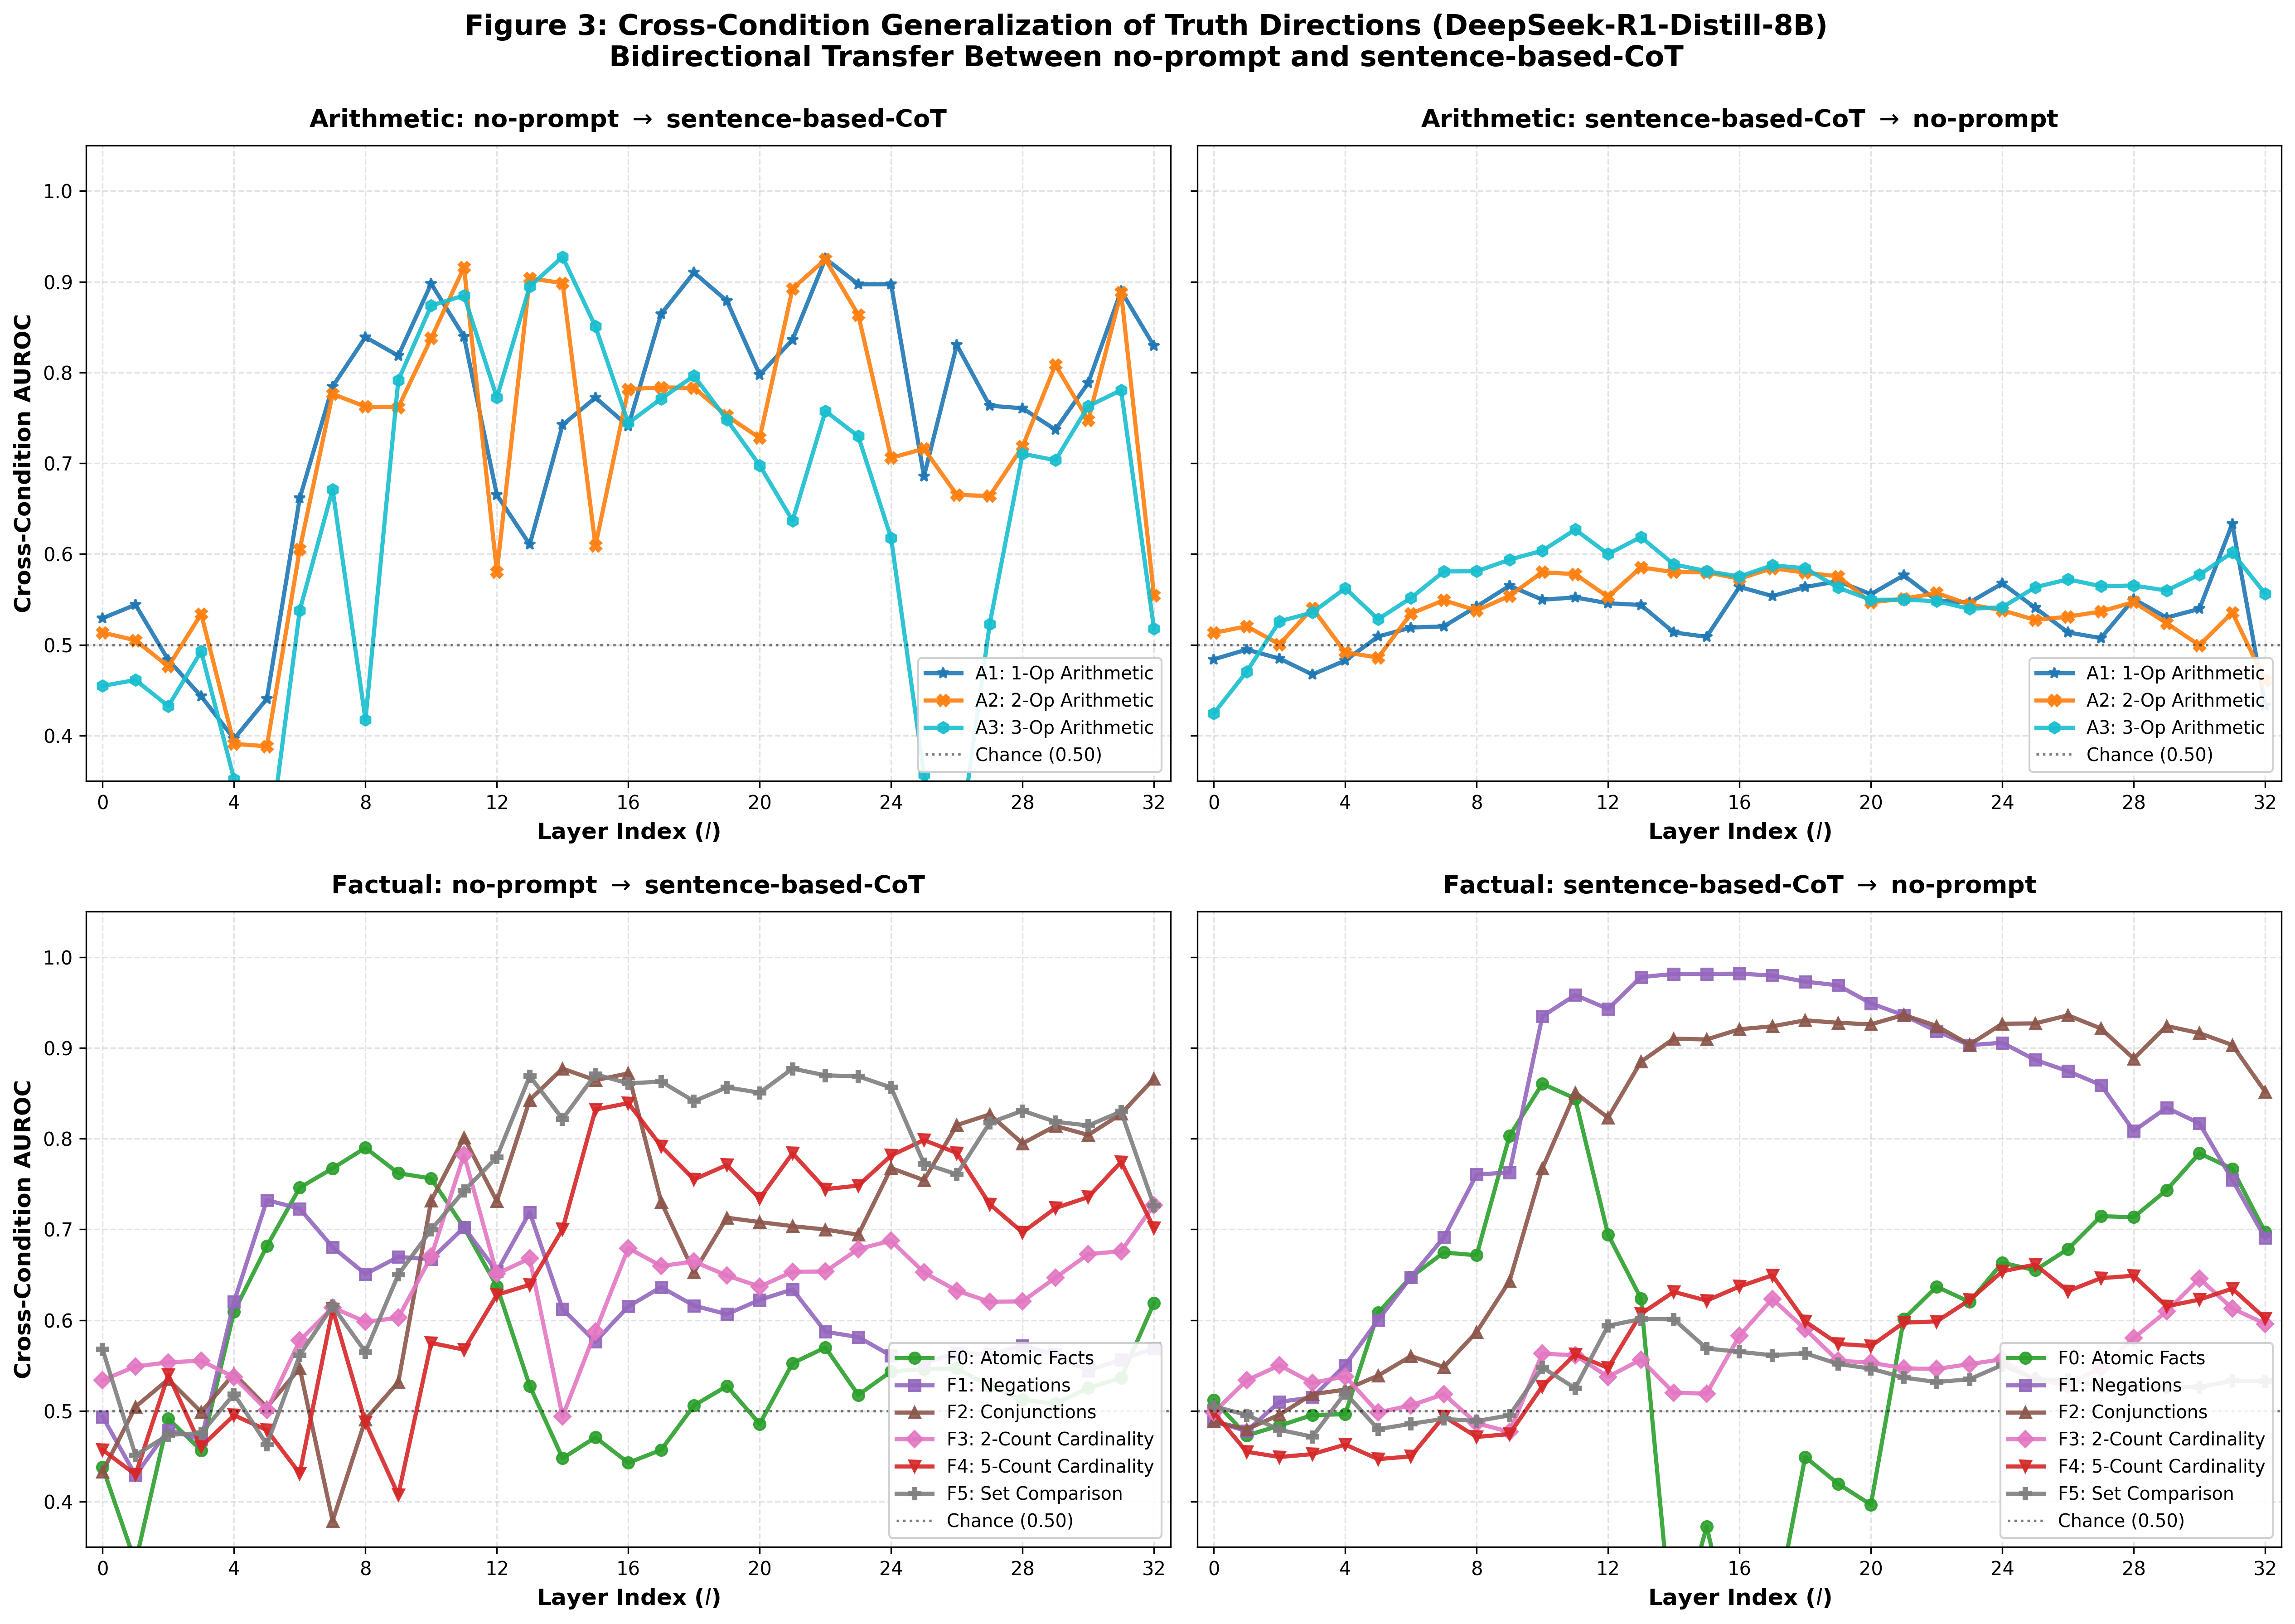

In [9]:
from IPython.display import Image, display

output_figures_dir = os.path.join(ROOT_DIR, 'experiments', 'figures', 'figure_3')
os.makedirs(output_figures_dir, exist_ok=True)

ARITH_TASKS = ['A1', 'A2', 'A3']
FACT_TASKS = ['F0', 'F1', 'F2', 'F3', 'F4', 'F5']

def slug(cond):
    return cond.replace('-', '_')

STYLE_MAP = {
    'A1': {'color': '#1f77b4', 'marker': '*', 'label': 'A1: 1-Op Arithmetic'},
    'A2': {'color': '#ff7f0e', 'marker': 'X', 'label': 'A2: 2-Op Arithmetic'},
    'A3': {'color': '#17becf', 'marker': 'h', 'label': 'A3: 3-Op Arithmetic'},
    'F0': {'color': '#2ca02c', 'marker': 'o', 'label': 'F0: Atomic Facts'},
    'F1': {'color': '#9467bd', 'marker': 's', 'label': 'F1: Negations'},
    'F2': {'color': '#8c564b', 'marker': '^', 'label': 'F2: Conjunctions'},
    'F3': {'color': '#e377c2', 'marker': 'D', 'label': 'F3: 2-Count Cardinality'},
    'F4': {'color': '#d62728', 'marker': 'v', 'label': 'F4: 5-Count Cardinality'},
    'F5': {'color': '#7f7f7f', 'marker': 'P', 'label': 'F5: Set Comparison'},
}

def load_cross_data(csv_path, cond_a, cond_b):
    df = pd.read_csv(csv_path)
    mask = (
        (df['model'] == 'deepseek-r1-distill-8b') &
        (df['train_task'] == df['test_task']) &
        (
            ((df['train_condition'] == cond_a) & (df['test_condition'] == cond_b)) |
            ((df['train_condition'] == cond_b) & (df['test_condition'] == cond_a))
        )
    )
    cross_df = df[mask].copy()
    cross_df['layer'] = cross_df['layer'].astype(int)
    cross_df['auroc'] = cross_df['auroc'].astype(float)
    return cross_df

def plot_panel(ax, sub_df, tasks, title, show_ylabel=True):
    for task in tasks:
        cfg = STYLE_MAP[task]
        task_data = sub_df[sub_df['train_task'] == task].sort_values('layer')
        if len(task_data) > 0:
            ax.plot(
                task_data['layer'],
                task_data['auroc'],
                color=cfg['color'],
                marker=cfg['marker'],
                markersize=6,
                linewidth=2.2,
                alpha=0.9,
                label=cfg['label'],
            )
    ax.axhline(0.5, color='black', linestyle=':', alpha=0.5, linewidth=1.3, label='Chance (0.50)')
    ax.set_xlabel('Layer Index ($l$)', fontsize=12, fontweight='bold')
    if show_ylabel:
        ax.set_ylabel('Cross-Condition AUROC', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_ylim(0.35, 1.05)
    ax.set_xlim(-0.5, num_layers - 0.5)
    ax.set_xticks(range(0, num_layers, 4))
    ax.grid(True, linestyle='--', alpha=0.35)
    ax.legend(loc='lower right', fontsize=9.5, framealpha=0.9)

def save_fig(df, tr_cond, te_cond, tasks, title, filename):
    sub_df = df[(df['train_condition'] == tr_cond) & (df['test_condition'] == te_cond)]
    if len(sub_df) == 0:
        print(f'Skipped (no rows): {filename}')
        return
    fig, ax = plt.subplots(figsize=(8.5, 6))
    plot_panel(ax, sub_df, tasks, title, show_ylabel=True)
    plt.tight_layout()
    out_path = os.path.join(output_figures_dir, filename)
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f'Saved: {filename}')

df_cross = load_cross_data(CSV_PATH, condition_A, condition_B)
print(f'Loaded {len(df_cross)} cross-condition rows for {condition_A} <-> {condition_B}')

AB, BA = f'{condition_A}_to_{condition_B}', f'{condition_B}_to_{condition_A}'

# 1-4. Per-domain, per-direction figures
for tasks, domain_label, domain_slug in [
    (ARITH_TASKS, 'Arithmetic Reasoning ($A_1-A_3$)', 'arithmetic'),
    (FACT_TASKS, 'Factual & Compositional Reasoning ($F_0-F_5$)', 'factual'),
]:
    save_fig(df_cross, condition_A, condition_B, tasks,
             f'{domain_label}\nTrain {condition_A} $\\to$ Test {condition_B}',
             f'figure_3_{domain_slug}_{slug(AB)}.png')
    save_fig(df_cross, condition_B, condition_A, tasks,
             f'{domain_label}\nTrain {condition_B} $\\to$ Test {condition_A}',
             f'figure_3_{domain_slug}_{slug(BA)}.png')

# 5. Comprehensive 2x2 Comparison Grid
dir_ab_df = df_cross[(df_cross['train_condition'] == condition_A) & (df_cross['test_condition'] == condition_B)]
dir_ba_df = df_cross[(df_cross['train_condition'] == condition_B) & (df_cross['test_condition'] == condition_A)]

if len(dir_ab_df) and len(dir_ba_df):
    fig, axes = plt.subplots(2, 2, figsize=(17, 12), sharey=True)
    plot_panel(axes[0, 0], dir_ab_df, ARITH_TASKS, f'Arithmetic: {condition_A} $\\to$ {condition_B}', show_ylabel=True)
    plot_panel(axes[0, 1], dir_ba_df, ARITH_TASKS, f'Arithmetic: {condition_B} $\\to$ {condition_A}', show_ylabel=False)
    plot_panel(axes[1, 0], dir_ab_df, FACT_TASKS, f'Factual: {condition_A} $\\to$ {condition_B}', show_ylabel=True)
    plot_panel(axes[1, 1], dir_ba_df, FACT_TASKS, f'Factual: {condition_B} $\\to$ {condition_A}', show_ylabel=False)

    plt.suptitle(
        'Figure 3: Cross-Condition Generalization of Truth Directions (DeepSeek-R1-Distill-8B)\n'
        f'Bidirectional Transfer Between {condition_A} and {condition_B}',
        fontsize=15,
        fontweight='bold',
        y=0.995,
    )
    plt.tight_layout()
    comp_path = os.path.join(output_figures_dir, f'figure_3_cross_condition_comprehensive_{slug(AB)}.png')
    plt.savefig(comp_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f'Saved: {os.path.basename(comp_path)}')
    display(Image(filename=comp_path))
else:
    print('Skipped comprehensive grid: one or both directions have no rows.')

In [ ]:
# Export the cross-condition rows for the current pair (used when running on Colab and
# copying results back to the local repo; a no-op worth skipping when running locally).
df_db = pd.read_csv(CSV_PATH)
cross_df = df_db[
    (df_db['model'] == 'deepseek-r1-distill-8b') &
    (df_db['train_task'] == df_db['test_task']) &
    (
        ((df_db['train_condition'] == condition_A) & (df_db['test_condition'] == condition_B)) |
        ((df_db['train_condition'] == condition_B) & (df_db['test_condition'] == condition_A))
    )
]
print(f'{len(cross_df)} rows for {condition_A} <-> {condition_B}')
print('EXPORT_CSV_START')
print(cross_df.to_csv(index=False))
print('EXPORT_CSV_END')

for fname in sorted(os.listdir(output_figures_dir)):
    if fname.endswith('.png') and (slug(AB) in fname or slug(BA) in fname):
        display(Image(filename=os.path.join(output_figures_dir, fname)))